# Bayesian A/B Testing

## Overview

Bayesian A/B testing frames the question as: "given the data, what do we believe about the effect?" It produces a posterior distribution over the effect size — directly answering questions like "what is the probability that treatment is better than control?"

**Frequentist vs Bayesian:**

| Question | Frequentist | Bayesian |
|---|---|---|
| "Is treatment better?" | p-value (indirect) | P(treatment > control \| data) |
| Stopping rule | Fixed n required | Can stop anytime (with care) |
| Prior knowledge | Not incorporated | Incorporated via prior |
| Result | Reject/fail to reject | Full posterior distribution |

**Conjugate priors (analytical):**
- Binary rate: Beta prior → Beta posterior
- Continuous mean: Normal prior → Normal posterior (known σ)
- Count rate: Gamma prior → Gamma posterior

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

rng = np.random.default_rng(42)
print("Bayesian A/B testing for ecological restoration experiments")
print("Beta-Binomial model: probability of restoration 'success' per site")

Bayesian A/B testing for ecological restoration experiments
Beta-Binomial model: probability of restoration 'success' per site


---
## Beta-Binomial Model for Binary Outcomes

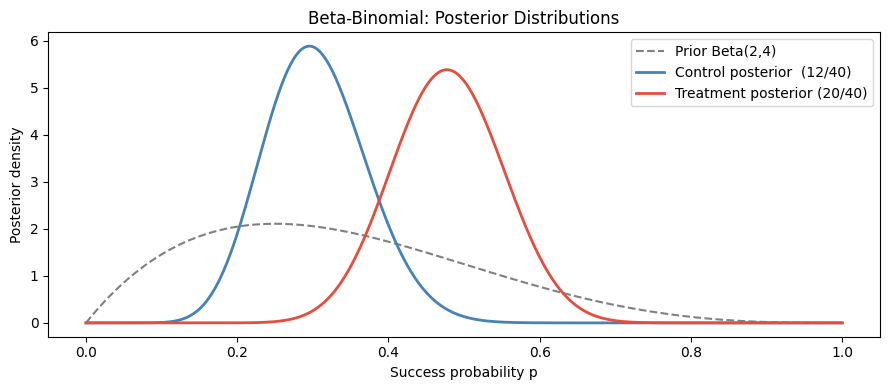

Control  posterior: mean=0.304, 95% CrI: 0.182–0.443
Treatment posterior: mean=0.478, 95% CrI: 0.337–0.621


In [2]:
# Scenario: success = site achieves target species richness after restoration
# Control arm: 12 successes out of 40 sites
# Treatment arm: 20 successes out of 40 sites
n_ctrl,  s_ctrl  = 40, 12   # n, successes
n_trt,   s_trt   = 40, 20

# Prior: Beta(2, 4) = weakly informative, centred near 30% success
alpha_prior, beta_prior = 2, 4

# Posterior: Beta(alpha + successes, beta + failures)
post_ctrl = stats.beta(alpha_prior + s_ctrl, beta_prior + n_ctrl - s_ctrl)
post_trt  = stats.beta(alpha_prior + s_trt,  beta_prior + n_trt  - s_trt)

x = np.linspace(0, 1, 500)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, stats.beta(alpha_prior, beta_prior).pdf(x),
        '--', color='grey', lw=1.5, label='Prior Beta(2,4)')
ax.plot(x, post_ctrl.pdf(x), color='steelblue', lw=2,
        label=f'Control posterior  ({s_ctrl}/{n_ctrl})')
ax.plot(x, post_trt.pdf(x), color='#e74c3c', lw=2,
        label=f'Treatment posterior ({s_trt}/{n_trt})')
ax.set_xlabel('Success probability p'); ax.set_ylabel('Posterior density')
ax.set_title('Beta-Binomial: Posterior Distributions')
ax.legend(); plt.tight_layout(); plt.show()
print(f"Control  posterior: mean={post_ctrl.mean():.3f}, 95% CrI: {post_ctrl.ppf(0.025):.3f}–{post_ctrl.ppf(0.975):.3f}")
print(f"Treatment posterior: mean={post_trt.mean():.3f}, 95% CrI: {post_trt.ppf(0.025):.3f}–{post_trt.ppf(0.975):.3f}")

---
## Probability of Superiority and Expected Uplift

P(treatment > control | data) = 0.9590
Expected uplift: 0.1743  95% CrI: [-0.0225, 0.3644]
P(uplift > 5pp | data)        = 0.8947


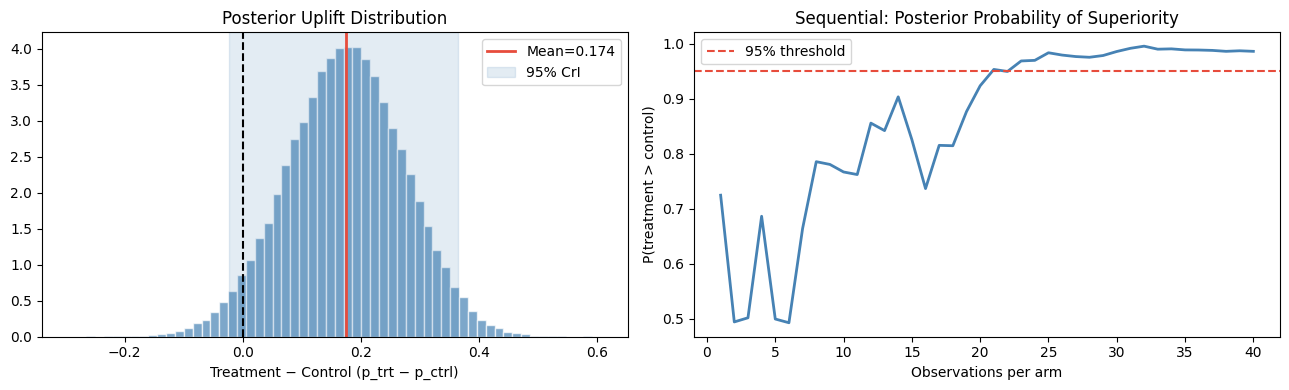

In [3]:
# Monte Carlo: P(treatment > control)
N_MC = 100_000
samples_ctrl = post_ctrl.rvs(N_MC, random_state=42)
samples_trt  = post_trt.rvs(N_MC, random_state=43)
p_superior   = (samples_trt > samples_ctrl).mean()
uplift       = samples_trt - samples_ctrl
print(f"P(treatment > control | data) = {p_superior:.4f}")
print(f"Expected uplift: {uplift.mean():.4f}  95% CrI: [{np.percentile(uplift,2.5):.4f}, {np.percentile(uplift,97.5):.4f}]")

# Probability of meaningful uplift (> 5 percentage points)
p_meaningful = (uplift > 0.05).mean()
print(f"P(uplift > 5pp | data)        = {p_meaningful:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(uplift, bins=60, color='steelblue', alpha=0.7, density=True, edgecolor='white')
axes[0].axvline(0, color='black', lw=1.5, linestyle='--')
axes[0].axvline(uplift.mean(), color='#e74c3c', lw=2, label=f'Mean={uplift.mean():.3f}')
axes[0].axvspan(np.percentile(uplift,2.5), np.percentile(uplift,97.5),
                alpha=0.15, color='steelblue', label='95% CrI')
axes[0].set_xlabel('Treatment − Control (p_trt − p_ctrl)')
axes[0].set_title('Posterior Uplift Distribution')
axes[0].legend()

# Sequential updating: posterior after each observation
successes_stream = np.concatenate([rng.binomial(1, 0.5, n_trt),
                                    rng.binomial(1, 0.3, n_ctrl)])
a_t, b_t = alpha_prior, beta_prior
a_c, b_c = alpha_prior, beta_prior
p_sup_seq = []
for i in range(1, n_trt+1):
    a_t += successes_stream[i-1]; b_t += 1-successes_stream[i-1]
    a_c += successes_stream[n_trt+i-1]; b_c += 1-successes_stream[n_trt+i-1]
    s_t2 = stats.beta(a_t, b_t).rvs(10000, random_state=i)
    s_c2 = stats.beta(a_c, b_c).rvs(10000, random_state=i+1)
    p_sup_seq.append((s_t2 > s_c2).mean())
axes[1].plot(range(1,n_trt+1), p_sup_seq, color='steelblue', lw=2)
axes[1].axhline(0.95, color='#e74c3c', lw=1.5, linestyle='--', label='95% threshold')
axes[1].set_xlabel('Observations per arm'); axes[1].set_ylabel('P(treatment > control)')
axes[1].set_title('Sequential: Posterior Probability of Superiority')
axes[1].legend()
plt.tight_layout(); plt.show()

---
## Bayesian t-test for Continuous Outcomes

In [4]:
# Continuous: species richness — normal-normal conjugate model
control_obs   = rng.normal(15.0, 5.0, 50)
treatment_obs = rng.normal(17.5, 5.2, 50)

# Approximate Bayesian computation using PyMC-style sampling
# Without PyMC: use analytical normal posterior (known variance approximation)
def normal_posterior(obs, mu0=15.0, sigma0=5.0, sigma_known=5.0):
    n = len(obs)
    x_bar = obs.mean()
    # Posterior mean and variance
    var_post = 1 / (1/sigma0**2 + n/sigma_known**2)
    mu_post  = var_post * (mu0/sigma0**2 + n*x_bar/sigma_known**2)
    return mu_post, np.sqrt(var_post)

mu_ctrl, sd_ctrl = normal_posterior(control_obs, mu0=15.0)
mu_trt,  sd_trt  = normal_posterior(treatment_obs, mu0=15.0)

# Sample from posteriors
N_MC = 50_000
post_ctrl_c = rng.normal(mu_ctrl, sd_ctrl, N_MC)
post_trt_c  = rng.normal(mu_trt,  sd_trt,  N_MC)
diff_c      = post_trt_c - post_ctrl_c
print(f"Continuous outcome posterior:")
print(f"  Control   posterior mean: {mu_ctrl:.3f} ± {sd_ctrl:.3f}")
print(f"  Treatment posterior mean: {mu_trt:.3f} ± {sd_trt:.3f}")
print(f"  P(treatment > control):   {(diff_c > 0).mean():.4f}")
print(f"  Expected difference:      {diff_c.mean():.3f}  95% CrI: [{np.percentile(diff_c,2.5):.3f}, {np.percentile(diff_c,97.5):.3f}]")

Continuous outcome posterior:
  Control   posterior mean: 14.334 ± 0.700
  Treatment posterior mean: 16.907 ± 0.700
  P(treatment > control):   0.9950
  Expected difference:      2.567  95% CrI: [0.634, 4.515]


ROPE analysis (practically equivalent if |delta| <= 1 species):
  P(in ROPE):          0.0551  -> practically equivalent
  P(treatment better): 0.9447  -> treatment meaningfully better
  P(control better):   0.0003  -> control meaningfully better


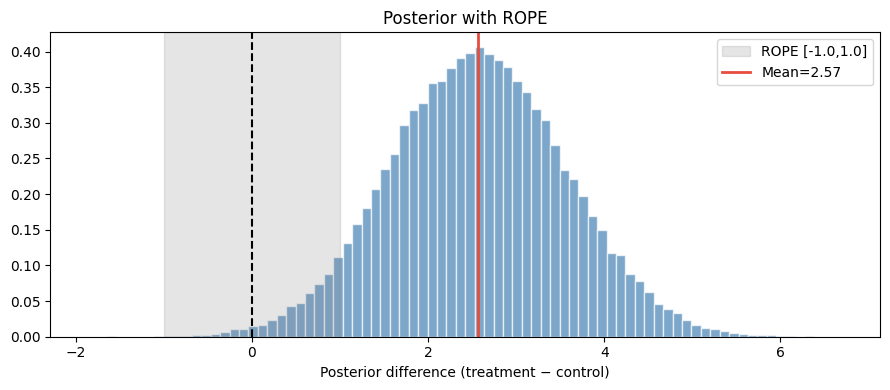

In [5]:
# Region of Practical Equivalence (ROPE)
rope_lo, rope_hi = -1.0, 1.0   # differences within ±1 species = practically equivalent
p_in_rope  = ((diff_c >= rope_lo) & (diff_c <= rope_hi)).mean()
p_above    = (diff_c > rope_hi).mean()
p_below    = (diff_c < rope_lo).mean()
print(f"ROPE analysis (practically equivalent if |delta| <= 1 species):")
print(f"  P(in ROPE):          {p_in_rope:.4f}  -> practically equivalent")
print(f"  P(treatment better): {p_above:.4f}  -> treatment meaningfully better")
print(f"  P(control better):   {p_below:.4f}  -> control meaningfully better")
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(diff_c, bins=80, color='steelblue', alpha=0.7, density=True, edgecolor='white')
ax.axvspan(rope_lo, rope_hi, alpha=0.2, color='grey', label=f'ROPE [{rope_lo},{rope_hi}]')
ax.axvline(diff_c.mean(), color='#e74c3c', lw=2, label=f'Mean={diff_c.mean():.2f}')
ax.axvline(0, color='black', lw=1.5, linestyle='--')
ax.set_xlabel('Posterior difference (treatment − control)')
ax.set_title('Posterior with ROPE'); ax.legend()
plt.tight_layout(); plt.show()

---

## Common Pitfalls

**1. Using a flat (uninformative) prior when domain knowledge exists**  
A Beta(1,1) uniform prior says all success probabilities from 0% to 100% are equally plausible — which is rarely true in practice. Weakly informative priors (e.g. Beta(2,10) for a rare event) stabilise estimates with small samples and improve calibration. Always encode at least a rough prior expectation from historical data or domain knowledge.

**2. Stopping as soon as P(treatment > control) > 0.95 without a pre-specified stopping rule**  
Continuously monitoring and stopping at any time P(superiority) crosses a threshold inflates the effective Type I error rate even in Bayesian frameworks. Pre-specify stopping rules, maximum sample sizes, and interim analysis schedules before data collection begins.

**3. Confusing the credible interval with the confidence interval**  
A 95% Bayesian credible interval means "there is a 95% probability the parameter lies in this range, given the data and prior." A frequentist 95% confidence interval means "95% of intervals constructed this way contain the true parameter." These are different statements and are only numerically similar with uninformative priors.

**4. Using Monte Carlo sample size to compute P(superiority) without checking convergence**  
With N=1,000 samples, P(superiority) estimates near 0.99 have standard error ≈ 0.003 — acceptable. But estimates near 0.999 require N > 100,000 for stable results. Always use enough samples for the precision level required, especially for tail probabilities.

**5. Setting the ROPE based on what makes the treatment win rather than domain relevance**  
The ROPE (Region of Practical Equivalence) should be defined before seeing results, based on what effect size is meaningfully different in the real world. Choosing the ROPE after seeing the posterior to ensure the desired decision outcome is circular reasoning.

---
*python_methods_library - Samantha McGarrigle*